In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from wp_math import *
from wp_util import *
from wp_radius_small import warp_radius_search_small
from wp_compactHash import *
# Convert Warp arrays back to PyTorch tensors using wp.t\o_torch() for direct GPU access
from radius_util import AdjacencyList
from wp_util import castTorchToWarpAsBuiltins
from warp.types import vector
from wp_autograd import warpWrapper, WarpFunctionWrapper
from wp_density import *
from radius_util import *
from radius_naive import *

wp.config.verify_autograd_array_access = True
wp.config.verbose = True

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/winchenbach/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:
import torchCompactRadius as tcr
from torchCompactRadius import radiusSearch, volumeToSupport

In [5]:
def runTCRCompact(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearch(
        PointCloud(queryPositions, querySupports),
        PointCloud(referencePositions, referenceSupports),
        mode = mode, domain = domain, 
        hashMapLength = hashMapLength,
        algorithm = 'compact',
        format = 'coo'
    )
    
def runTCRNaive(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearch(
        PointCloud(queryPositions, querySupports),
        PointCloud(referencePositions, referenceSupports),
        mode = mode, domain = domain, 
        hashMapLength = hashMapLength,
        algorithm = 'naive',
        format = 'coo'
    )
    
def runNaive(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusNaive(queryPositions, referencePositions, 
                  querySupports, referenceSupports, 
                  domain.periodic, domain.min, domain.max, mode = mode)
    
def runWarpSmall(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return warp_radius_search_small(
    queryPositions, referencePositions, querySupports, referenceSupports, domain.periodic, domain, mode = mode)
    
def runWarpCompact(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearchCompactHashMap(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        periodicity = domain.periodic, domainDescription=domain,
        mode = mode, hashMapLength=hashMapLength
)

In [6]:
import time

def measureTime(fn, queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    initialMemory = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    begin.record()
    
    adjacency = fn(queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength)
    
    end.record()
    torch.cuda.synchronize()
    finalMemory = torch.cuda.memory_allocated()
    maxMemory = torch.cuda.max_memory_allocated()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return adjacency, gpuTime, cpuTime, initialMemory, finalMemory, maxMemory

In [7]:
algorithms = [
    (runTCRCompact, 'compact[TCR]'),
    (runTCRNaive, 'naive[TCR]'),
    (runNaive, 'naive'),
    (runWarpSmall, 'warp_small'),
    (runWarpCompact, 'warp_compact')
]

algorithmsNoNaive = [
    (runTCRCompact, 'compact[TCR]'),
    (runWarpCompact, 'warp_compact')
]

In [8]:
def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

In [9]:
from tqdm.autonotebook import tqdm


def runBenchmarks(device, targetNumNeighbors, nx, dim, periodic, mode, skipNaive):
    device = torch.device(device)
    numParticles = nx**dim
    hashMapLength = getNextPrime(numParticles)
    periodic = False
    x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

    pointCloud = PointCloud(x, h)
    queryPositions = pointCloud.positions.contiguous()
    querySupports = pointCloud.supports
    referencePositions = pointCloud.positions.contiguous()
    referenceSupports = pointCloud.supports
        
        
    algos = algorithmsNoNaive if skipNaive else algorithms
    benchmarkData = []
    for fn, name in (tq:= tqdm(algos, leave = False)):
        tq.set_description(f'Benchmarking {name}')
        for _ in tqdm(range(16), leave = False):        
            adjacency, gpuTime, cpuTime, initialMemory, finalMemory, maxMemory = measureTime(fn,
                queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
            )
            
            benchmarkData.append({
                'iter': _,
                'algorithm': name,
                'gpuTime': gpuTime,
                'cpuTime': cpuTime,
                'initialMemory': initialMemory,
                'finalMemory': finalMemory,
                'maxMemory': maxMemory,
                'nx': nx,
                'numParticles': numParticles,
                'targetNumNeighbors': targetNumNeighbors,
                'dim': dim,
                'periodic': periodic,
            })
            
    return benchmarkData

/tmp/ipykernel_28746/103668484.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [25]:
numParticles = [2**n for n in range(10, 20)]

overallData = []

_ = runBenchmarks('cuda', 50, 10, 2, False, 'gather', skipNaive = False)
        
for num in (tq := tqdm(numParticles)):
    for dim in (tqd := tqdm([2,3], leave = False)):
        tqd.set_description(f'Running Dimension {dim} with {num} Particles')
        nx = int(num ** (1/dim))

        benchmarkData = runBenchmarks('cuda', 50, nx, dim, False, 'gather', skipNaive = num > 2**14)
        overallData.extend(benchmarkData)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

In [26]:
import pandas as pd
import seaborn as sns

In [27]:
dataset = pd.DataFrame(overallData)

display(dataset)

,iter,algorithm,gpuTime,cpuTime,initialMemory,finalMemory,maxMemory,nx,numParticles,targetNumNeighbors,dim,periodic
0,0,compact[TCR],5.984256,0.006908,12599296,13264896,13663232,32,1024,50,2,False
1,1,compact[TCR],6.870016,0.007336,13264896,13930496,14328832,32,1024,50,2,False
2,2,compact[TCR],5.749760,0.006194,13264896,13930496,14328832,32,1024,50,2,False
3,3,compact[TCR],5.499904,0.005913,13264896,13930496,14328832,32,1024,50,2,False
4,4,compact[TCR],6.742016,0.007235,13264896,13930496,14328832,32,1024,50,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1115,11,warp_compact,35.354626,0.036025,29462016,37654016,85494784,80,512000,50,3,False
1116,12,warp_compact,35.928062,0.036496,28971008,37654016,86280704,80,512000,50,3,False
1117,13,warp_compact,35.757057,0.037223,29462016,37654016,85494784,80,512000,50,3,False
1118,14,warp_compact,37.112831,0.037706,28971008,37654016,86280704,80,512000,50,3,False


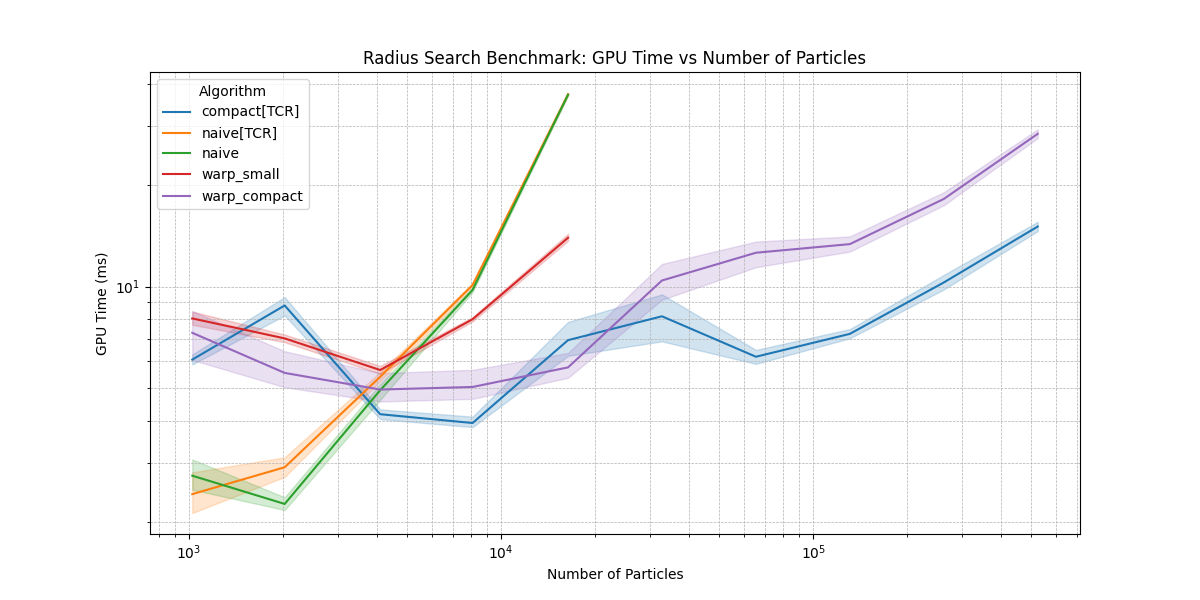

In [29]:
import matplotlib.pyplot as plt
fig, axis = plt.subplots(1,1, figsize = (12,6))
# display(fig)
sns.lineplot(data = dataset[dataset['dim'] == 2], x = 'numParticles', y = 'gpuTime', hue = 'algorithm', ax = axis)
axis.set_xscale('log')
axis.set_yscale('log')
axis.set_xlabel('Number of Particles')
axis.set_ylabel('GPU Time (ms)')
axis.set_title('Radius Search Benchmark: GPU Time vs Number of Particles')
plt.legend(title='Algorithm')
plt.grid(True, which="both", ls="--", linewidth=0.5)
# plt.show()

In [15]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

def evalWarpDensity(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):

        begin = torch.cuda.Event(enable_timing=True)
        adjacencyTime = torch.cuda.Event(enable_timing=True)
        densityTime = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        cpuBegin = time.time()
        initialMemory = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        begin.record()
        
        adjacency = runWarpCompact(
                queryPositions, querySupports, referencePositions, referenceSupports, domain, 'gather', hashMapLength
        )
        
        adjacencyTime.record()
        torch.cuda.synchronize()
        cpuAdjacencyTime = time.time()
        densityTime.record()
                
        densities_warp = computeDensity_warpBackend(
                queryPositions, queryPositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                domain,
                mode = mode,
                adjacency = adjacency
        )
        
        
        end.record()
        torch.cuda.synchronize()
        finalMemory = torch.cuda.memory_allocated()
        maxMemory = torch.cuda.max_memory_allocated()
        cpuEnd = time.time()
        gpuTime = begin.elapsed_time(end)
        cpuTime = cpuEnd - cpuBegin
        
        return {
                'gpuTime[Total]': gpuTime,
                'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
                'gpuTime[Density]': densityTime.elapsed_time(end),
                'cpuTime[Total]': cpuTime,
                'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
                'cpuTime[Density]': cpuEnd - cpuAdjacencyTime,
                'initialMemory': initialMemory,
                'finalMemory': finalMemory,
                'maxMemory': maxMemory
        }


In [16]:
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates

def evalDiffSPHDensity(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):

    begin = torch.cuda.Event(enable_timing=True)
    adjacencyTime = torch.cuda.Event(enable_timing=True)
    densityTime = torch.cuda.Event(enable_timing=True)
    kernelTimeBegin = torch.cuda.Event(enable_timing=True)
    kernelTimeEnd = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    initialMemory = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    begin.record()
    
    particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))


    simulationState = BasicState(
        positions = particles_l.positions,
        supports = particles_l.supports,
        masses = particles_l.masses,
        densities = particles_l.densities,        
        velocities = torch.zeros_like(referencePositions),
        kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
    )

    # neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
    neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)
        
    adjacencyTime.record()
    torch.cuda.synchronize()
    cpuAdjacencyTime = time.time()
    kernelTimeBegin.record()
        
    state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland4, KernelType.Wendland4, False, False, False)
    kernelTimeEnd.record()
    torch.cuda.synchronize()
    densityTimeCPU = time.time()
    densityTime.record()

    densities = computeDensity(simulationState,  KernelType.Wendland4, state.get('noghost'), SupportScheme.Gather)
    end.record()
    torch.cuda.synchronize()
    endCPUTime = time.time()
    
    return {
                'gpuTime[Total]': begin.elapsed_time(end),
                'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
                'gpuTime[Kernel]': kernelTimeBegin.elapsed_time(kernelTimeEnd),
                'gpuTime[Density]': densityTime.elapsed_time(end) + kernelTimeBegin.elapsed_time(kernelTimeEnd) ,
                'cpuTime[Total]': endCPUTime - cpuBegin,
                'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
                'cpuTime[Kernel]': densityTimeCPU - cpuAdjacencyTime,
                'cpuTime[Density]': endCPUTime - densityTimeCPU,
                'initialMemory': initialMemory,
                'finalMemory': torch.cuda.memory_allocated(),
                'maxMemory': torch.cuda.max_memory_allocated()
        }



In [17]:

def benchmarkDensity(
        device, targetNumNeighbors, nx, dim, periodic, mode
):
        device = torch.device(device)
        numParticles = nx**dim
        hashMapLength = getNextPrime(numParticles)
        periodic = False
        x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device)

        pointCloud = PointCloud(x, h)
        queryPositions = pointCloud.positions.contiguous()
        querySupports = pointCloud.supports
        referencePositions = pointCloud.positions.contiguous()
        referenceSupports = pointCloud.supports

        queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
        referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

        benchmarkData = []

        for i in range(16):
                wpData = evalWarpDensity(
                        queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
                        referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
                        domain=domain, mode=mode, hashMapLength=hashMapLength
                )
                wpData['device'] = device
                wpData['numNeighbors'] = targetNumNeighbors
                wpData['nx'] = nx
                wpData['dim'] = dim
                wpData['numParticles'] = numParticles
                wpData['backend'] = 'warp'
                
                benchmarkData.append(wpData)

        for i in range(16):
                dSPHData = evalDiffSPHDensity(
                        queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
                        referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
                        domain=domain, mode=mode, hashMapLength=hashMapLength
                )
                dSPHData['device'] = device
                dSPHData['numNeighbors'] = targetNumNeighbors
                dSPHData['nx'] = nx
                dSPHData['dim'] = dim
                dSPHData['numParticles'] = numParticles
                dSPHData['backend'] = 'diffSPH'
                benchmarkData.append(dSPHData)
                
        return benchmarkData


In [30]:
numParticles = [2**n for n in range(10, 21)]

overallComputeData = []

_ = benchmarkDensity('cuda', 50, 10, 2, False, 'gather')
for num in (tq := tqdm(numParticles)):
    for dim in (tqd := tqdm([2], leave = False)):
        tqd.set_description(f'Running Dimension {dim} with {num} Particles')
        nx = int(num ** (1/dim))

        benchmarkData = benchmarkDensity('cuda', 50, nx, dim, False, 'gather')
        overallComputeData.extend(benchmarkData)

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
pdData = pd.DataFrame(overallComputeData)

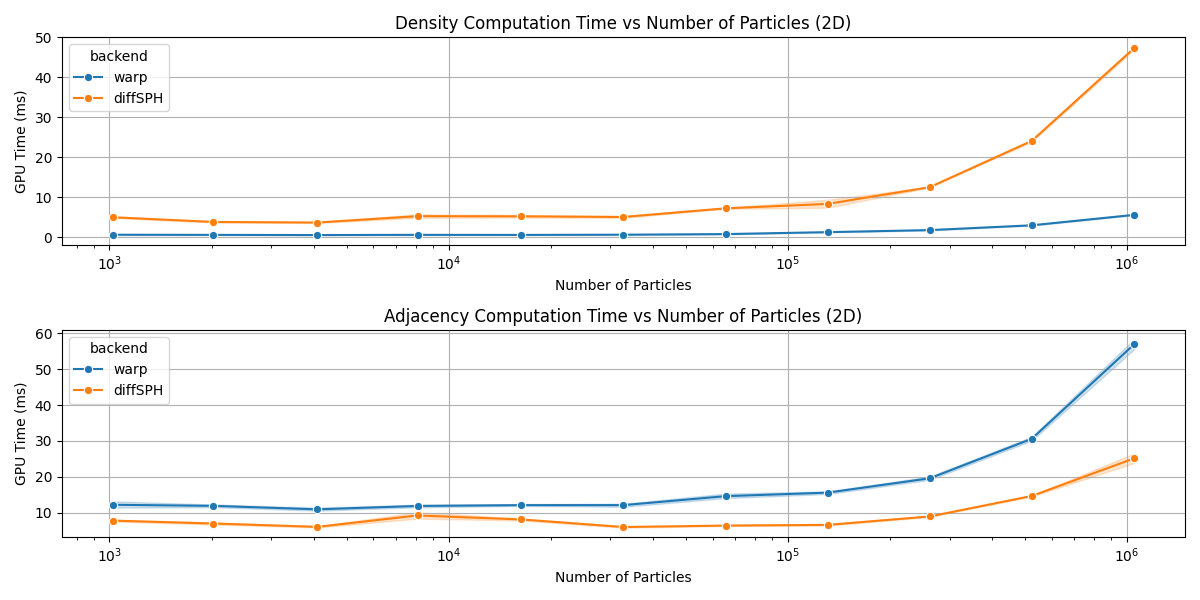

In [32]:
fig, axis = plt.subplots(2,1, figsize = (12,6), squeeze = False)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[Density]', hue = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
# axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Density Computation Time vs Number of Particles (2D)')
axis[0,0].grid(True)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[Adjacency]', hue = 'backend', ax = axis[1,0], marker = 'o')
axis[1,0].set_xscale('log')
# axis[1,0].set_yscale('log')
axis[1,0].set_xlabel('Number of Particles')
axis[1,0].set_ylabel('GPU Time (ms)')
axis[1,0].set_title('Adjacency Computation Time vs Number of Particles (2D)')
axis[1,0].grid(True)

fig.tight_layout()

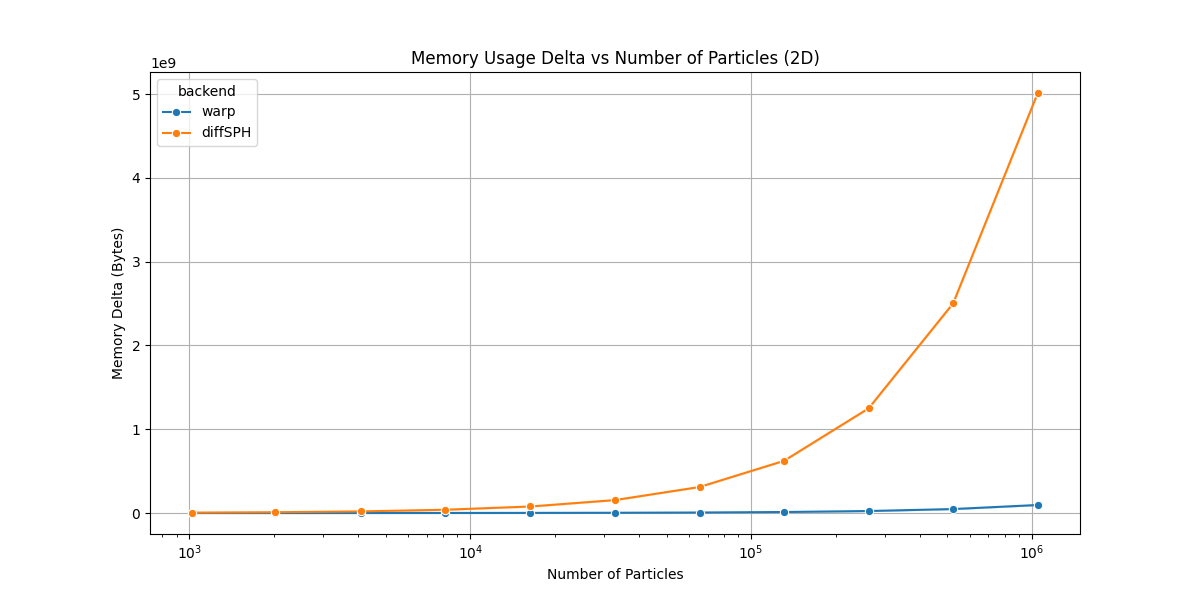

In [34]:
pdData['memoryDelta'] = pdData['maxMemory'] - pdData['initialMemory']

fig,axis = plt.subplots(1,1, figsize = (12,6), squeeze = False)
sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'memoryDelta', hue = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('Memory Delta (Bytes)')
axis[0,0].set_title('Memory Usage Delta vs Number of Particles (2D)')
axis[0,0].grid(True)